In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

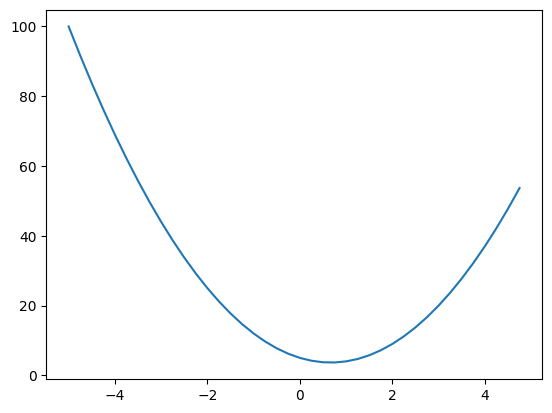

In [3]:
def f(x):
  return 3*x**2 - 4*x+5

xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges


def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


class Value:
    def __init__(self, data, _children=(), _op="", label=""): # _children is a tuple
      self.data = data
      self._prev = set(_children)
      self._op = _op
      self.label = label
      self.grad = 0.0
      self._backward = lambda: None


    def __repr__(self):
      return f"Value(data={self.data})"


    def __mul__(self, other):
      other = other if isinstance(other, Value) else Value(other)
      out = Value(self.data * other.data, (self, other), "*")

      # chain rule:
      # dz/dx = dz/dy * dy/dx
      # e.g out = self * other
      # self = 2, other = 1, so out = 2
      # dout/dout = 1
      # dout/dself = other, that is 1 meaning if self changes 1 step, out changes 1 step
      # dout/dother = self, that is 2 meaning if other changes 1 step, out changes 2 steps
      def _backward():
        self.grad += other.data * out.grad
        other.grad += self.data * out.grad

      # so why _backward is a callback?
      # because you don't know what is out.grad yet when you multiply here.
      # specifically, you don't know what are the following operations after the multiply,
      # the final gradient will pass down from the chain, so out.grad at this point is unknown.

      out._backward = _backward

      return out


    # allows thing like: 2 * a, where a is a Value
    def __rmul__(self, other):
      return self * other


    def __add__(self, other):
      other = other if isinstance(other, Value) else Value(other)

      out = Value(self.data + other.data, (self, other), "+")

      # consider b = a + a, when b.backward, a.grad is overwritten twice
      # therefore we can't do self.grad = 1.0 * out.grad
      # we need to do self.grad += 1.0 * out.grad
      def _backward():
        self.grad += 1.0 * out.grad
        other.grad += 1.0 * out.grad

      out._backward = _backward

      return out

    def __radd__(self, other):
      return self + other


    def __neg__(self):
      return self * -1


    def __sub__(self, other):
      return self + (-other)


    def __truediv__(self, other):
      return self * other**-1


    def __pow__(self, other):
      assert isinstance(other, (int, float)), "only supporting int/float powers for now"

      out = Value(self.data**other, (self, ), f'**{other}')

      def _backward():
        self.grad += other * self.data ** (other-1) * out.grad

      out._backward = _backward

      return out


    def tanh(self):
      x = self.data
      t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
      out = Value(t, (self, ), 'tanh')

      def _backward():
        self.grad += (1 - t**2) * out.grad

      out._backward = _backward

      return out


    def backward(self):
      topo = []
      visited = set()

      def build_topo(v):
        if v not in visited:
          visited.add(v)
          for child in v._prev:
            build_topo(child)
          topo.append(v)

      build_topo(self)

      self.grad = 1.0 # gradient of myself is: 1
      for node in reversed(topo):
        node._backward()


    def exp(self):
      x = self.data
      out = Value(math.exp(x), (self, ), 'exp')

      def _backward():
        self.grad += out.data * out.grad

      out._backward = _backward

      return out

In [6]:
a = Value(2.0)
b = Value(4.0)
a - b

Value(data=-2.0)

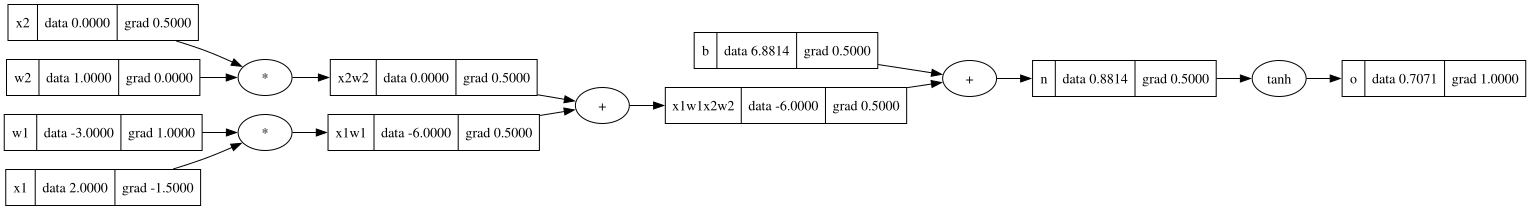

In [7]:
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
x1w1 = x1*w1; x1w1.label = "x1w1"
x2w2 = x2*w2; x2w2.label = "x2w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1x2w2"
b = Value(6.8813735870195421, label="b")
n = x1w1x2w2 + b; n.label = "n"
o = n.tanh(); o.label = "o"

o.grad = 1.0
o.backward()
draw_dot(o)

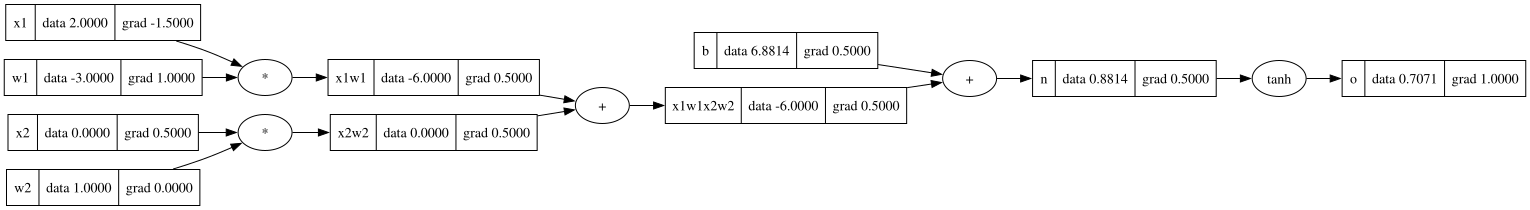

In [8]:
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
x1w1 = x1*w1; x1w1.label = "x1w1"
x2w2 = x2*w2; x2w2.label = "x2w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1x2w2"
b = Value(6.8813735870195421, label="b")
n = x1w1x2w2 + b; n.label = "n"
o = n.tanh(); o.label = "o"

o.grad = 1.0
o.backward()
draw_dot(o)

In [9]:
import torch

x1 = torch.Tensor([2.0]).double();  x1.requires_grad = True
x2 = torch.Tensor([0.0]).double();  x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double();  w2.requires_grad = True
b = torch.Tensor([6.8813735870195421]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b;
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('x1', x1.grad.item())
print('x2', x2.grad.item())
print('w1', w1.grad.item())
print('w2', w2.grad.item())



0.7071066904050358
x1 -1.5000003851533106
x2 0.5000001283844369
w1 1.0000002567688737
w2 0.0


In [10]:
import random

class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1, 1))

  def __call__(self, x):
    act = sum((wi*xi  for wi, xi in zip(self.w, x)), self.b)
    out =  act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]


class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for n in self.neurons for p in n.parameters()]


class MLP:
  def __init__(self, nin, nouts): # nouts: a list of nout
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]


  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for l in self.layers for p in l.parameters()]





In [11]:
nnn = MLP(3, [4, 4, 1])
nnn.parameters()

[Value(data=0.354770900303367),
 Value(data=-0.1504144716325333),
 Value(data=0.8906685252160829),
 Value(data=0.06014926857939096),
 Value(data=0.342281080149462),
 Value(data=-0.5077843775712849),
 Value(data=0.5927890650142096),
 Value(data=0.9972627665656253),
 Value(data=-0.025884928619896996),
 Value(data=0.8652575932428155),
 Value(data=-0.6418886869066782),
 Value(data=-0.10453289775822783),
 Value(data=0.01680328710006318),
 Value(data=0.7183080721635617),
 Value(data=-0.4065462496003758),
 Value(data=-0.5951570417105714),
 Value(data=-0.28774384651541385),
 Value(data=0.6899251119038596),
 Value(data=-0.7312166263281226),
 Value(data=-0.295089267151077),
 Value(data=0.5236463719997322),
 Value(data=0.0893597272806892),
 Value(data=-0.7243572886087899),
 Value(data=0.3546696524127373),
 Value(data=0.8769374854718159),
 Value(data=-0.5718074368150916),
 Value(data=0.8379655221474556),
 Value(data=0.7948669726086521),
 Value(data=-0.5660999164917722),
 Value(data=-0.075154797506

In [12]:
xs = [
    [2., 3., -1.],
    [3., -1., 0.5],
    [0.5, 1., 1.],
    [1., 1., -1.]
]
ys = [1., -1., -1., 1]



ypred = [nnn(x) for x in xs]

loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

loss

Value(data=4.12505420451517)

In [13]:
learning_rate = 0.01
steps = 100
for _ in range(steps):
  # zero the gradients! since grad is accumulated, it's common bug
  for p in nnn.parameters():
    p.grad = 0.0

  ypred = [nnn(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  loss.backward()
  print(loss)

  for p in nnn.parameters():
    p.data += -learning_rate * p.grad

Value(data=4.12505420451517)
Value(data=3.22793091780138)
Value(data=2.4289305031457697)
Value(data=1.7980414656337314)
Value(data=1.3461150886083173)
Value(data=1.0368410358296223)
Value(data=0.8252551595999985)
Value(data=0.6770429080242661)
Value(data=0.5699051383017284)
Value(data=0.48998067733422707)
Value(data=0.4286246655563094)
Value(data=0.3803261299073331)
Value(data=0.34147250960401454)
Value(data=0.3096270279660148)
Value(data=0.28310080621988754)
Value(data=0.2606937760641672)
Value(data=0.2415337368880932)
Value(data=0.22497376509563893)
Value(data=0.2105251801797406)
Value(data=0.19781271725156063)
Value(data=0.18654390019209616)
Value(data=0.17648770024288252)
Value(data=0.16745939330671156)
Value(data=0.15930963560153527)
Value(data=0.15191646143024345)
Value(data=0.145179338634712)
Value(data=0.13901469517158335)
Value(data=0.13335251232411643)
Value(data=0.12813370140836133)
Value(data=0.12330806298881308)
Value(data=0.11883268407076948)
Value(data=0.1146706680650522

In [14]:
ypred = [nnn(x) for x in xs]
ypred

[Value(data=0.9096145559933647),
 Value(data=-0.9386216985571284),
 Value(data=-0.9024644445844426),
 Value(data=0.8912248144754079)]